UWAGA - zadania znjadują się w całym pliku, nie na końcu - są oznaczone numerem oraz znacznikiem 🎯 (jest ich 9)

# Wersjonowanie danych

Wersjonowanie danych to proces śledzenia zmian w zbiorach danych w czasie.
Pozwala ono:
- zapewnić **reproduktywność eksperymentów**,
- odtworzyć poprzednie wersje danych,
- współdzielić dane w zespole bez ich duplikowania.

Podobnie jak **Git** śledzi zmiany w kodzie, **DVC (Data Version Control)** śledzi zmiany w danych i modelach.

In [ ]:
!pip install -q dvc kaggle

In [ ]:
!mkdir lab5-fdl

mkdir: cannot create directory ‘lab5-fdl’: File exists


Uwaga - jeśli odpalamy skrypt kolejny raz to jest szansa, że musimy wyczyścić nasze repo:

In [ ]:
!rm -rf .dvc

Inicjalizujemy repozytorium

In [ ]:
!cd lab5-fdl/
!git init
!dvc init

Reinitialized existing Git repository in /content/.git/
Initialized DVC repository.

You can now commit the changes to git.

+---------------------------------------------------------------------+
|                                                                     |
|        DVC has enabled anonymous aggregate usage analytics.         |
|     Read the analytics documentation (and how to opt-out) here:     |
|             <https://dvc.org/doc/user-guide/analytics>              |
|                                                                     |
+---------------------------------------------------------------------+

What's next?
------------
- Check out the documentation: <https://dvc.org/doc>
- Get help and share ideas: <https://dvc.org/chat>
- Star us on GitHub: <https://github.com/iterative/dvc>


W rzeczywistości nie mamy potrzeby niczego uplodować, więc stowrzymy sobie sztuczny remote - lokalne repozytorium do którego będziemy zapisywać zmiany.

In [ ]:
!mkdir fake-repo

mkdir: cannot create directory ‘fake-repo’: File exists


In [ ]:
!dvc remote add -d local_repo fake-repo

Setting 'local_repo' as a default remote.


In [ ]:
! git config --global user.name "Myroslav Natalchenko" # TODO: uzupełnij swoimi danymi
! git config --global user.email "s30023@pjwstk.edu.pl" # TODO: uzupełnij swoimi danymi, mail nie musi być prawdziwy

In [ ]:
! cd lab5-fdl && git status

On branch master
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   ../.dvc/config

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	../.config/
	../sample_data/

no changes added to commit (use "git add" and/or "git commit -a")


In [ ]:
!cd lab5-fdl && git commit -m "Init DVC"

On branch master
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   ../.dvc/config

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	../.config/
	../sample_data/

no changes added to commit (use "git add" and/or "git commit -a")


Zainicjowaliśmy nasze repozytoria - teraz pora podłączyć się do Kaggle

1. Wchodzimy na kaggle (proszę się zarejestrować uczelnianym lub prywatnym mailem)

2. Klikamy na nasz profil po prawej stronie, następnie ustawienia (settings)

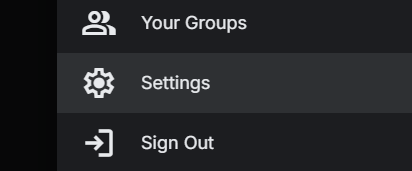

3. W sekcji API tworzymy nowy token - Create New Token

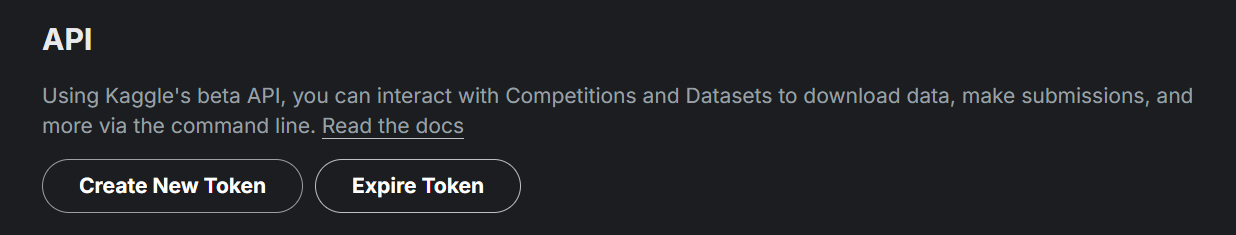

4. Wrzucamy pobrany plik do plików colabowych (okienko z boku, można przeciągnąć i upuścić)

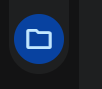

Tak to powinno wyglądać:

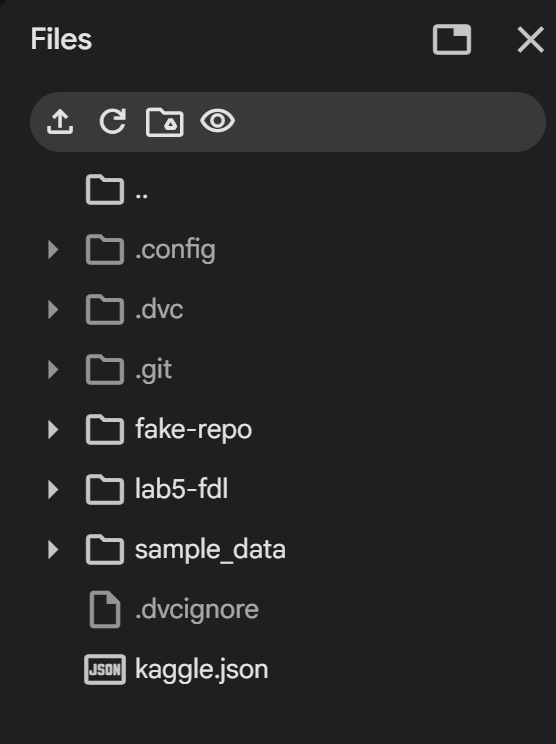

Aby colab dobrze odczytywał nasze "credentials" do kaggle, musimy utworzyć folder .kaggle i wrzucić tam nasze dane. Nie zapominamy dodać też uprawnienia do pliku.

In [ ]:
!mkdir -p /root/.kaggle
!mv kaggle.json /root/.kaggle
!chmod 600 /root/.kaggle/kaggle.json

Jeśli tutaj pojawią nam się różne datasety, to znaczy że dobrze skonfigurowaliśmy nasz dostęp do kaggle:

In [ ]:
!kaggle datasets list

ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
ahmeduzaki/global-earthquake-tsunami-risk-assessment-dataset    Global Earthquake-Tsunami Risk Assessment Dataset        16151  2025-10-01 16:35:53.273000          18631        631  1.0              
jaderz/hospital-beds-management                                 Hospital Beds Management                                 47583  2025-10-03 09:21:58.590000          15693        363  1.0              
ahmadrazakashif/bmw-worldwide-sales-records-20102024            BMW Worldwide Sales Records (2010–2024)                 853348  2025-09-20 14:39:45.280000          21252        409  1.0              


# Zadanie

Chcemy zbadać dataset filmów i seriali na Netflixie, ale mamy mało czasu i ktoś inny po nas będzie kontynuował pracę. Dlatego musimy przygotować pliki i zapisywać naszą pracę 🤖

**Cel:** chcemy pogrupować filmy i seriale w klastry. Użyjemy do tego KMeans, które pogrupuje nam rekordy w grupy podobnych pozycji.

**Zadanie:**
1. Pobrać dataset
2. Przygotować dataset
3. Stworzyć klastry

## Pobranie surowych danych

Pobierzemy nasz dataset: https://www.kaggle.com/datasets/anandshaw2001/netflix-movies-and-tv-shows

In [ ]:
!kaggle datasets download anandshaw2001/netflix-movies-and-tv-shows

Dataset URL: https://www.kaggle.com/datasets/anandshaw2001/netflix-movies-and-tv-shows
License(s): CC0-1.0
  0% 0.00/1.34M [00:00<?, ?B/s]
100% 1.34M/1.34M [00:00<00:00, 714MB/s]


Rozpakujmy i przenieśmy dane do naszego folderu roboczego

In [ ]:
!unzip -d lab5-fdl/data netflix-movies-and-tv-shows.zip

Archive:  netflix-movies-and-tv-shows.zip
  inflating: lab5-fdl/data/netflix_titles.csv  


Dodajemy nasze dane do dvc:

In [ ]:
!dvc add lab5-fdl/data/netflix_titles.csv

⠋ Checking graph
Adding...:   0% 0/1 [00:00<?, ?file/s{'info': ''}]
!
          |0.00 [00:00,     ?file/s]
                                    
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
Adding lab5-fdl/data/netflix_titles.csv to cache:   0% 0/1 [00:00<?, ?file/s]
  0% 0/1 [00:00<?, ?file/s{'info': ''}]                                      
                                       
  0% 0/1 [00:00<?, ?files/s]
  0% 0/1 [00:00<?, ?files/s{'info': ''}]
Adding...: 100% 1/1 [00:00<00:00, 12.67file/s{'info': ''}]

To track the changes with git, run:

	git add lab5-fdl/data/.gitignore lab5-fdl/data/netflix_titles.csv.dvc

To enable auto staging, run:

	dvc config core.autostage true


Dodajmy informacje jakie dane dodaliśmy:

In [ ]:
!git add -f lab5-fdl/data/netflix_titles.csv
!git commit -m "Raw Netflix data added"

[master 7101d03] Raw Netflix data added
 1 file changed, 8810 insertions(+)
 create mode 100644 lab5-fdl/data/netflix_titles.csv


Tak wygląda nasz folder roboczy:

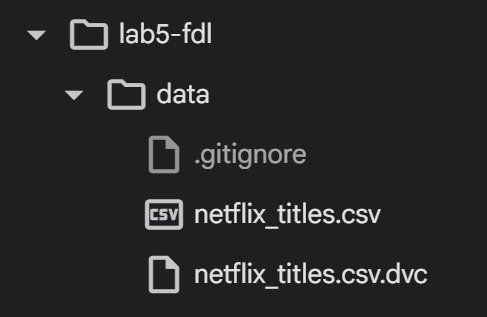

## Przygotowanie danych dla modelu

In [ ]:
import pandas as pd
import numpy as np

1. 🎯 Wczytaj dane z pliku csv do dataframe df

In [ ]:
df = pd.read_csv('lab5-fdl/data/netflix_titles.csv')

In [ ]:
df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8617,s8618,Movie,Trash,Stephen Daldry,"Wagner Moura, Martin Sheen, Rooney Mara, Selto...","United Kingdom, Brazil, Germany","January 1, 2019",2014,R,114 min,"Dramas, Independent Movies, Thrillers",Three poor Brazilian teens find something susp...
8464,s8465,Movie,The Prince,Brian A. Miller,"Jason Patric, Bruce Willis, John Cusack, Rain,...","United States, United Kingdom","February 22, 2019",2014,R,91 min,Action & Adventure,A former Mafia hit man living quietly as a mec...
7208,s7209,Movie,King's Ransom,Jeffrey W. Byrd,"Anthony Anderson, Jay Mohr, Kellita Smith, Nic...","United States, Canada","November 1, 2019",2005,PG-13,98 min,"Action & Adventure, Comedies","A wealthy, despicable businessman comes to the..."
6322,s6323,Movie,Black Hawk Down,Ridley Scott,"Josh Hartnett, Ewan McGregor, Tom Sizemore, Er...","United States, United Kingdom","January 1, 2019",2001,R,144 min,"Action & Adventure, Dramas",When U.S. forces attempt to capture two underl...
1791,s1792,TV Show,Chico Bon Bon: Monkey with a Tool Belt,NaN,"Robbie Daymond, Dayci Brookshire, Anthony Tede...",United States,"October 27, 2020",2020,TV-Y,4 Seasons,Kids' TV,"Armed with tools and engineering smarts, monke..."


W tym momencie polecam wejść na kaggle i poczytać co znaczą poszczególne kolumny jeśli nie jesteśmy pewni 😺

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## Co będzie nas interesowało w klasteryzacji?

Chcemy mozemy zwracać uwagę na różne kolumny ze zbioru, ale my skupimy się tylko na najważniejszych:

In [ ]:
features = ['type', 'country', 'rating', 'listed_in', 'release_year', 'duration']
df_features = df[features].copy()

In [ ]:
df_features.sample(5)

,type,country,rating,listed_in,release_year,duration
7358,Movie,Argentina,TV-PG,"Documentaries, International Movies, Sports Mo...",2016,98 min
1187,Movie,United States,R,Thrillers,2021,115 min
7842,TV Show,United States,TV-MA,"Crime TV Shows, TV Dramas, TV Mysteries",2016,4 Seasons
2301,TV Show,United States,TV-G,Reality TV,1993,1 Season
1881,Movie,United States,R,Comedies,2020,96 min


## Pozbycie się pustych wartości

Zaczniemy od usunięcia pustych wartości

In [ ]:
df_features.isnull().sum()

,0
type,0
country,831
rating,4
listed_in,0
release_year,0
duration,3


2. 🎯 W różny sposób pozbędziemy się Nulli:

    - country - puste wartości uzupełnijmy nową kategorią "Unknown"
    - rekordy z pustymi polami rating oraz duration usuńmy - są to dla nas kluczowe informacje, ale puste rekordy stanowią niewielki procent

In [ ]:
# Zmiana country
df_features.loc[df_features['country'].isna(), 'country']= "Unknown"

# Zmiana duration i rating
df_features.dropna(subset=['rating', 'duration'], inplace=True)

In [ ]:
# Sprawdzenie braków po czyszczeniu
print(df_features.isna().sum())

type            0
country         0
rating          0
listed_in       0
release_year    0
duration        0
dtype: int64


## Wartości kategoryczne, listy

In [ ]:
df_features

,type,country,rating,listed_in,release_year,duration
0,Movie,United States,PG-13,Documentaries,2020,90 min
1,TV Show,South Africa,TV-MA,"International TV Shows, TV Dramas, TV Mysteries",2021,2 Seasons
2,TV Show,Unknown,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",2021,1 Season
3,TV Show,Unknown,TV-MA,"Docuseries, Reality TV",2021,1 Season
4,TV Show,India,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",2021,2 Seasons
...,...,...,...,...,...,...
8802,Movie,United States,R,"Cult Movies, Dramas, Thrillers",2007,158 min
8803,TV Show,Unknown,TV-Y7,"Kids' TV, Korean TV Shows, TV Comedies",2018,2 Seasons
8804,Movie,United States,R,"Comedies, Horror Movies",2009,88 min
8805,Movie,United States,PG,"Children & Family Movies, Comedies",2006,88 min


In [ ]:
df_features['country'].unique()[:20]

array(['United States', 'South Africa', 'Unknown', 'India',
       'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
       'United Kingdom', 'Germany, Czech Republic', 'Mexico', 'Turkey',
       'Australia', 'United States, India, France', 'Finland',
       'China, Canada, United States',
       'South Africa, United States, Japan', 'Nigeria', 'Japan',
       'Spain, United States', 'France', 'Belgium',
       'United Kingdom, United States'], dtype=object)

Mamy tu nie mały problem:
1. Mamy wartości kategoryczne, które musimy zamienić na cyfry
2. W jednej kolumnie może występować kilka nazw (albo nazwy kraju albo kategoria filmu). Jeśli teraz zmienimy to na one-hot encoding to filmy z kategoriami: "Kids, Culinary" oraz "Culinary, Kids" będzie potraktowane jako dwie różne wartości kategoryczne.

3. 🎯 Zamień warości w `df_features['listed_in']` i `df_features['country']` na listę (podpowiedź: możesz podzielić przy użyciu `split(',')`)

In [ ]:
df_features['listed_in'] = df_features['listed_in'].str.split(', ')
df_features['country'] = df_features['country'].str.split(', ')

In [ ]:
df_features['listed_in'].iloc[4033]

['Dramas', 'Independent Movies', 'Romantic Movies']

In [ ]:
df_features['country'].iloc[3450]

['Canada', 'United States']

4. 🎯 Użyjemy MultiLabelBinarizer, który rozdzieli każde wystąpienie na osobną kolumnę oraz zaznaczy 1 w kategoriach/krajach które występują w tym przypadku. Przykład:

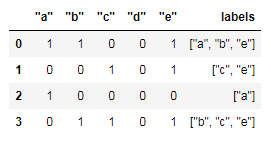

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

# MultiLabelBinarizer dla 'listed_in'
mlb_genres = MultiLabelBinarizer() # inicjalizacja
listed_in_encoded = mlb_genres.fit_transform(df_features['listed_in']) # dopasowujemy
listed_in_df = pd.DataFrame(
    listed_in_encoded,
    columns=[f"genre_{c}" for c in mlb_genres.classes_],
    index=df_features.index
)

# MultiLabelBinarizer dla 'country'
mlb_counties = MultiLabelBinarizer()
country_encoded = mlb_counties.fit_transform(df_features['country'])
country_df = pd.DataFrame(
    country_encoded,
    columns=[f"country_{c}" for c in mlb_counties.classes_],
    index=df_features.index
)

# Połącz wszystko z resztą cech
# Podpowiedź - możesz użyć pd.concat aby połączyć df z nowymi kolumnami oraz stary df bez kolumn listen_in oraz country
df_features = pd.concat([
    df_features.drop(columns=['listed_in', 'country']),
    listed_in_df,
    country_df
], axis=1)

In [ ]:
df_features

,type,rating,release_year,duration,genre_Action & Adventure,genre_Anime Features,genre_Anime Series,genre_British TV Shows,genre_Children & Family Movies,genre_Classic & Cult TV,...,"country_United Kingdom,",country_United States,"country_United States,",country_Unknown,country_Uruguay,country_Vatican City,country_Venezuela,country_Vietnam,country_West Germany,country_Zimbabwe
0,Movie,PG-13,2020,90 min,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,TV Show,TV-MA,2021,2 Seasons,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,TV Show,TV-MA,2021,1 Season,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,TV Show,TV-MA,2021,1 Season,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,TV Show,TV-MA,2021,2 Seasons,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,Movie,R,2007,158 min,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
8803,TV Show,TV-Y7,2018,2 Seasons,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
8804,Movie,R,2009,88 min,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
8805,Movie,PG,2006,88 min,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0


## Pozostałe wartości

Pozostały nam jeszcze 3 problemy:
1. Typ jest wartością tekstową: albo Movie albo TV Show
2. Rating to również wartość kategoryczna
3. Duration to albo minuty albo sezony

Rozprawmy się z tymi problemami

5. 🎯 Zamień duration na dwie kolumny - `duration_min` oraz `seasons`. Przenieś wartości do odpowiednich kolumn.

Przykład:
|Duration (będzie dropped)| duration_min | seasons |
|---|---|---|
| 90 min | 90 | 0 |
|2 Seasons | 0 | 2 |

Wartości których nie ma (np seasons dla rekordu podanego w minutach) możesz wypełnić najpierw NaN a następnie zamienić na 0

In [ ]:
df_features['duration_min'] = df_features['duration'].str.extract(r'(\d+) min')
df_features['seasons'] = df_features['duration'].str.extract(r'(\d+) Season')

df_features['duration_min'] = df_features['duration_min'].astype(float)
df_features['seasons'] = df_features['seasons'].astype(float)

# Możesz teraz usunąć starą kolumnę duration i jeśli masz NaN'y - zmienić je na 0
df_features[['duration_min', 'seasons']] = df_features[['duration_min', 'seasons']].fillna(0)
df_features.drop(columns=['duration'], inplace=True)

df_features.head(10)

,type,rating,release_year,genre_Action & Adventure,genre_Anime Features,genre_Anime Series,genre_British TV Shows,genre_Children & Family Movies,genre_Classic & Cult TV,genre_Classic Movies,...,"country_United States,",country_Unknown,country_Uruguay,country_Vatican City,country_Venezuela,country_Vietnam,country_West Germany,country_Zimbabwe,duration_min,seasons
0,Movie,PG-13,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,90.0,0.0
1,TV Show,TV-MA,2021,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0,2.0
2,TV Show,TV-MA,2021,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0.0,1.0
3,TV Show,TV-MA,2021,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0.0,1.0
4,TV Show,TV-MA,2021,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0,2.0
5,TV Show,TV-MA,2021,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0.0,1.0
6,Movie,PG,2021,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,91.0,0.0
7,Movie,TV-MA,1993,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,125.0,0.0
8,TV Show,TV-14,2021,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0.0,9.0
9,Movie,PG-13,2021,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,104.0,0.0


6. 🎯 Użyj `LabelEncoder` aby zmienić wartości `type` i `rating` na reprezentacje cyfrowe

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_type, le_rating = LabelEncoder(), LabelEncoder()

df_features['type'] = le_type.fit_transform(df_features['type'])
df_features['rating'] = le_rating.fit_transform(df_features['rating'])

Sprawdzamy:

In [ ]:
df_features.sample(5)

,type,rating,release_year,genre_Action & Adventure,genre_Anime Features,genre_Anime Series,genre_British TV Shows,genre_Children & Family Movies,genre_Classic & Cult TV,genre_Classic Movies,...,"country_United States,",country_Unknown,country_Uruguay,country_Vatican City,country_Venezuela,country_Vietnam,country_West Germany,country_Zimbabwe,duration_min,seasons
3890,0,9,2018,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,125.0,0.0
1750,1,6,2002,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0,6.0
6792,0,5,1994,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,118.0,0.0
6312,0,9,2018,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,66.0,0.0
7302,0,8,2018,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,84.0,0.0


## Skalowanie

Mamy juz teraz same wartości liczbowe, mozemy więc przeskalować te dane

7. 🎯 Użyj `StandardScaler` do przeskalowania `df_features`

In [ ]:
from sklearn.preprocessing import StandardScaler

sc_features = StandardScaler()
df_features_scaled = sc_features.fit_transform(df_features)

### PCA

Zbadajmy czy opłaca nam się zastosować PCA

8. 🎯 Utwórz wykres składowych PCA - y = wariancja, x = liczba składowych

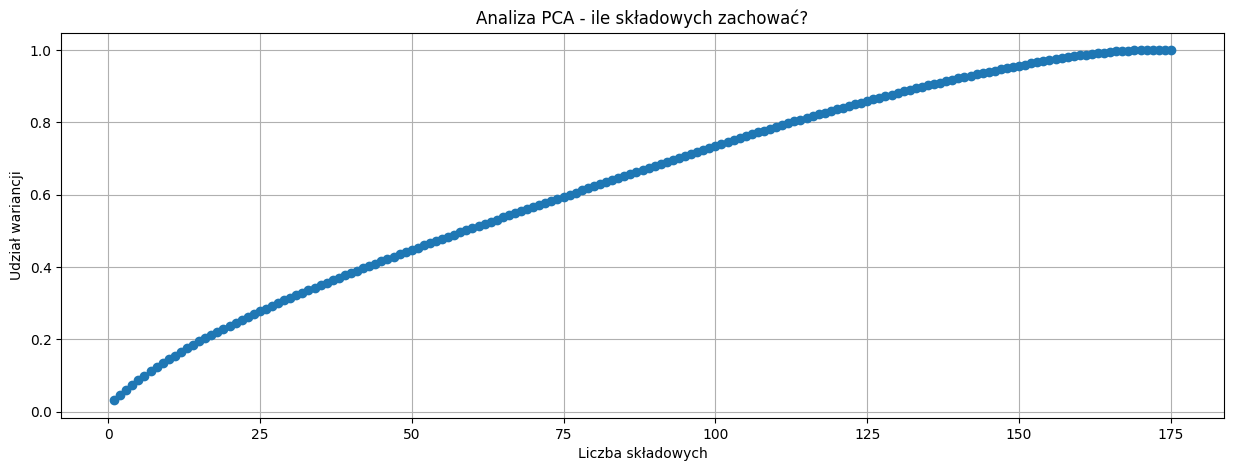

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA()
pca.fit(df_features_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(15, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.title('Analiza PCA - ile składowych zachować?')
plt.xlabel('Liczba składowych')
plt.ylabel('Udział wariancji')
plt.grid(True)
plt.show()

9. 🎯 Wybierz dowolną wartość n_componentes na podstawie wykresu (tą którą uważasz za słuszną) i przetransformuj dataset

In [217]:
from sklearn.decomposition import PCA

n_comp = 88
pca = PCA(n_components=n_comp)

df_features_after_pca = pca.fit_transform(df_features_scaled)

print(f"Udział wariancji przy {n_comp} z {df_features_scaled.shape[1]} składowych: {pca.explained_variance_ratio_.sum():.4f}")

Udział wariancji przy 88 z 175 składowych: 0.6689


## Zapiszmy nasze badania!

Ale zrobiliśmy dużo pracy - zapiszmy ją

In [218]:
np.save("lab5-fdl/netflix_pca.npy", df_features_after_pca)

In [219]:
!dvc add lab5-fdl/netflix_pca.npy
!git add lab5-fdl/netflix_pca.npy.dvc
!git commit -m "Add PCA-transformed Netflix data"

⠋ Checking graph
Adding...:   0% 0/1 [00:00<?, ?file/s{'info': ''}]
!
          |0.00 [00:00,     ?file/s]
                                    
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
Adding lab5-fdl/netflix_pca.npy to cache:   0% 0/1 [00:00<?, ?file/s]
  0% 0/1 [00:00<?, ?file/s{'info': ''}]                              
                                       
Checking out /content/lab5-fdl/netflix_pca.npy:   0% 0/1 [00:00<?, ?files/s]
  0% 0/1 [00:00<?, ?files/s{'info': ''}]                                    
Adding...: 100% 1/1 [00:00<00:00, 12.85file/s{'info': ''}]

To track the changes with git, run:

	git add lab5-fdl/netflix_pca.npy.dvc

To enable auto staging, run:

	dvc config core.autostage true
[master c6c556e] Add PCA-transformed Netflix data
 1 file changed, 2 insertions(+), 2 deletions(-)


Nie wiemy czy PCA jest tutaj sensowne - zapiszmy też pełny, przeskalowany zbiór

In [220]:
np.save("lab5-fdl/netflix_scaled.npy", df_features_scaled)

In [221]:
!dvc add lab5-fdl/netflix_scaled.npy
!git add lab5-fdl/netflix_scaled.npy.dvc
!git commit -m "Add Scaled Netflix data"

⠋ Checking graph
Adding...:   0% 0/1 [00:00<?, ?file/s{'info': ''}]
!
          |0.00 [00:00,     ?file/s]
                                    
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
Checking out /content/lab5-fdl/netflix_scaled.npy:   0% 0/1 [00:00<?, ?files/s]
  0% 0/1 [00:00<?, ?files/s{'info': ''}]                                       
Adding...: 100% 1/1 [00:00<00:00, 17.53file/s{'info': ''}]

To track the changes with git, run:

	git add lab5-fdl/netflix_scaled.npy.dvc

To enable auto staging, run:

	dvc config core.autostage true
On branch master
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   .dvc/config

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	fake-repo/
	lab5-fdl/.gitignore
	lab5-fdl/data/.gitignore
	lab5-fdl/data/netflix_titles.csv.dvc
	netflix-

## KMeans

W końcu dotarliśmy, do miejsca w któym możemy stworzyć nasz klaster

In [222]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

Wybierzmy konkretną ilość klastrów - wartość tą również mozemy dopasować ekperymentalnie

In [223]:
best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_features['cluster'] = kmeans.fit_predict(df_features_after_pca)

Dalej nie mamy czasu już dalej tego analizować, skończy to ktoś inny z zespołu - zapiszmy to koniecznie w DVC

In [224]:
import joblib
# zapis danych i etykiet klastrów
joblib.dump(kmeans, "lab5-fdl/netflix_kmeans.joblib")
df_features['cluster'].to_csv("lab5-fdl/netflix_clusters.csv", index=False)

In [225]:
!dvc add lab5-fdl/netflix_kmeans.joblib
!dvc add lab5-fdl/netflix_clusters.csv

⠋ Checking graph
Adding...:   0% 0/1 [00:00<?, ?file/s{'info': ''}]
!
          |0.00 [00:00,     ?file/s]
                                    
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
Adding lab5-fdl/netflix_kmeans.joblib to cache:   0% 0/1 [00:00<?, ?file/s]
  0% 0/1 [00:00<?, ?file/s{'info': ''}]                                    
                                       
  0% 0/1 [00:00<?, ?files/s]
  0% 0/1 [00:00<?, ?files/s{'info': ''}]
Adding...: 100% 1/1 [00:00<00:00, 21.43file/s{'info': ''}]

To track the changes with git, run:

	git add lab5-fdl/netflix_kmeans.joblib.dvc

To enable auto staging, run:

	dvc config core.autostage true
⠋ Checking graph
Adding...:   0% 0/1 [00:00<?, ?file/s{'info': ''}]
!
          |0.00 [00:00,     ?file/s]
                                    
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
Adding lab5-fdl/netflix_clusters.csv to cache:   0% 0/1 [00:00<?, 

In [226]:
!git add lab5-fdl/netflix_clusters.csv.dvc lab5-fdl/netflix_kmeans.joblib.dvc
!git status

On branch master
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   lab5-fdl/netflix_clusters.csv.dvc
	modified:   lab5-fdl/netflix_kmeans.joblib.dvc

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   .dvc/config

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	fake-repo/
	lab5-fdl/.gitignore
	lab5-fdl/data/.gitignore
	lab5-fdl/data/netflix_titles.csv.dvc
	netflix-movies-and-tv-shows.zip
	retrieved-lab5-fdl/
	sample_data/



In [227]:
!git commit -m "Add KMeans clustering results"

[master 7e327e0] Add KMeans clustering results
 2 files changed, 3 insertions(+), 3 deletions(-)


In [228]:
!dvc push

Pushing
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
Pushing to local:   0% 0/3 [00:00<?, ?file/s]
Pushing to local:   0% 0/3 [00:00<?, ?file/s{'info': ''}]
Pushing
3 files pushed


## Odzyskiwanie

Chyba jeszcze mamy chwilę - wczytajmy naszą pracę i sprawdźmy czy wszystko łąduje się poprawnie.

In [229]:
!mkdir retrieved-lab5-fdl

mkdir: cannot create directory ‘retrieved-lab5-fdl’: File exists


In [230]:
!dvc get /content lab5-fdl/netflix_kmeans.joblib -o retrieved-lab5-fdl/netflix_kmeans.joblib --force
!dvc get /content lab5-fdl/netflix_clusters.csv -o retrieved-lab5-fdl/netflix_clusters.csv --force
!dvc get /content lab5-fdl/netflix_pca.npy -o retrieved-lab5-fdl/netflix_pca.npy --force

Tak powinny wyglądać nasze pliki:

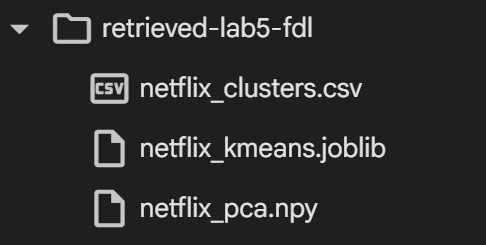

Wczytujemy potrzebne dane:

In [231]:
import numpy as np
import joblib
import pandas as pd

kmeans = joblib.load("retrieved-lab5-fdl/netflix_kmeans.joblib")
df_clusters = pd.read_csv("retrieved-lab5-fdl/netflix_clusters.csv")
downloaded_pca = np.load("retrieved-lab5-fdl/netflix_pca.npy")

In [232]:
df_clusters

,cluster
0,0
1,2
2,2
3,2
4,2
...,...
8795,0
8796,2
8797,0
8798,0


Super - widzimy że zapisały się nasze klastry, zwizualizujmy sobie to!

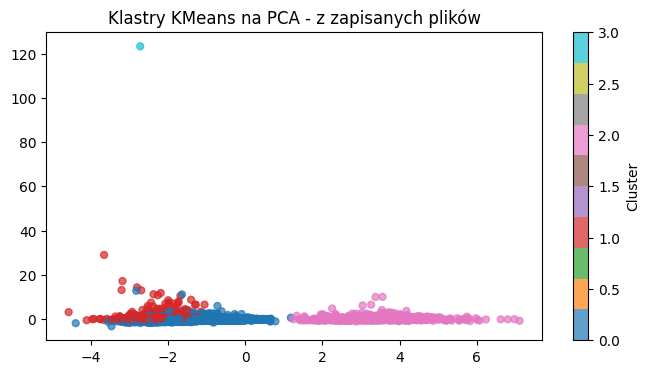

In [233]:
plt.figure(figsize=(8,4))
plt.scatter(
    downloaded_pca[:, 0], downloaded_pca[:, 1],
    c=df_clusters['cluster'], # etykiety klastrów
    cmap='tab10',
    s=25,
    alpha=0.7
)
plt.title("Klastry KMeans na PCA - z zapisanych plików")
plt.colorbar(label="Cluster")
plt.show()

Widzimy 4 rozdzielone klastry, każdy w innym kolorze - to grupy które model wydzielił wśród naszych filmów i seriali.

Teraz jesteśmy gotowi na poprawę i dopracowonie naszego sytsemu.... a może zrobi to ktoś inny? W końcu zapisaliśmy naszą pracę krok po kroku...